# Co-integration

In [111]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

def stream_pure_linear_scatter(total_frames=200):
    """
    New Notebook Baseline. Split screen layout:
    2/3 left for pure parallel sine waves, 1/3 right for the geometric scatter trajectory.
    Perfect linear link with zero noise (Y = 2 * X + 1).
    """
    max_x = 10 * 2 * np.pi
    x_space = np.linspace(0, max_x, total_frames)

    # 1. PURE SYNCHRONIZED SINE DATA (No noise)
    # Asset B (Reference / Independent variable X)
    asset_b_ref = 2.0 + 1.0 * np.sin(x_space)

    # Asset A (To be explained / Dependent variable Y)
    # Strictly twice the amplitude of Asset B + a constant shift of 1.0
    asset_a_exp = 2.0 * asset_b_ref + 1.0

    # 2. PREPARE THE ASYMMETRICAL LAYOUT ONCE
    # Width ratios [2, 1] splits the line: 2/3 for prices, 1/3 for scatter
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 5), gridspec_kw={'width_ratios': [2, 1]})

    # Left Panel Config (Time-Series)
    ax1.set_xlim(0, max_x)
    ax1.set_ylim(-0.5, 8.5)
    ax1.set_title("Synchronized Asset Prices", fontsize=11, fontweight="bold")
    ax1.set_xlabel("Time Timeline (Cycles)")
    ax1.set_ylabel("Asset Prices ($)")
    ax1.grid(True, linestyle="--", alpha=0.3)

    line_a, = ax1.plot([], [], color="dodgerblue", linewidth=2.5, label="Asset A (Explained, 2x Amp)")
    line_b, = ax1.plot([], [], color="orange", linewidth=2.5, label="Asset B (Reference, 1x Amp)")
    tip_a, = ax1.plot([], [], color="navy", marker="o", markersize=6)
    tip_b, = ax1.plot([], [], color="darkorange", marker="o", markersize=6)
    ax1.legend(loc="upper left")

    # Right Panel Config (Pure Scatter Plot)
    ax2.set_xlim(min(asset_b_ref) - 0.2, max(asset_b_ref) + 0.2)
    ax2.set_ylim(min(asset_a_exp) - 0.4, max(asset_a_exp) + 0.4)
    ax2.set_title("Linear Profile (Scatter)", fontsize=11, fontweight="bold")
    ax2.set_xlabel("Price: Asset B (Reference X)")
    ax2.set_ylabel("Price: Asset A (Explained Y)")
    ax2.grid(True, linestyle="--", alpha=0.3)

    # Initialize empty trajectory layer using simple plot handle for maximum performance
    scatter_dots, = ax2.plot([], [], color="purple", marker="o", linestyle="None", markersize=4, alpha=0.6)
    current_tip_dot, = ax2.plot([], [], color="black", marker="X", markersize=8)

    fig.tight_layout()

    # Historical caches vectors
    x_hist, a_hist, b_hist = [], [], []

    try:
        # 3. HIGH-SPEED ANIMATION LOOP (No sleep delays)
        for i in range(total_frames):
            cx = x_space[i]
            ca = asset_a_exp[i]
            cb = asset_b_ref[i]

            x_hist.append(cx)
            a_hist.append(ca)
            b_hist.append(cb)

            # Repaint Left Vector Layers
            line_a.set_data(x_hist, a_hist)
            tip_a.set_data([cx], [ca])
            line_b.set_data(x_hist, b_hist)
            tip_b.set_data([cx], [dark_b := cb])

            # Repaint Right Scatter Layers (X=Reference, Y=Explained)
            scatter_dots.set_data(b_hist, a_hist)
            current_tip_dot.set_data([cb], [ca])

            clear_output(wait=True)
            display(fig)

        plt.close(fig)

    except KeyboardInterrupt:
        print("\n[INFO] Dashboard stopped safely by user.")
    finally:
        plt.close(fig)


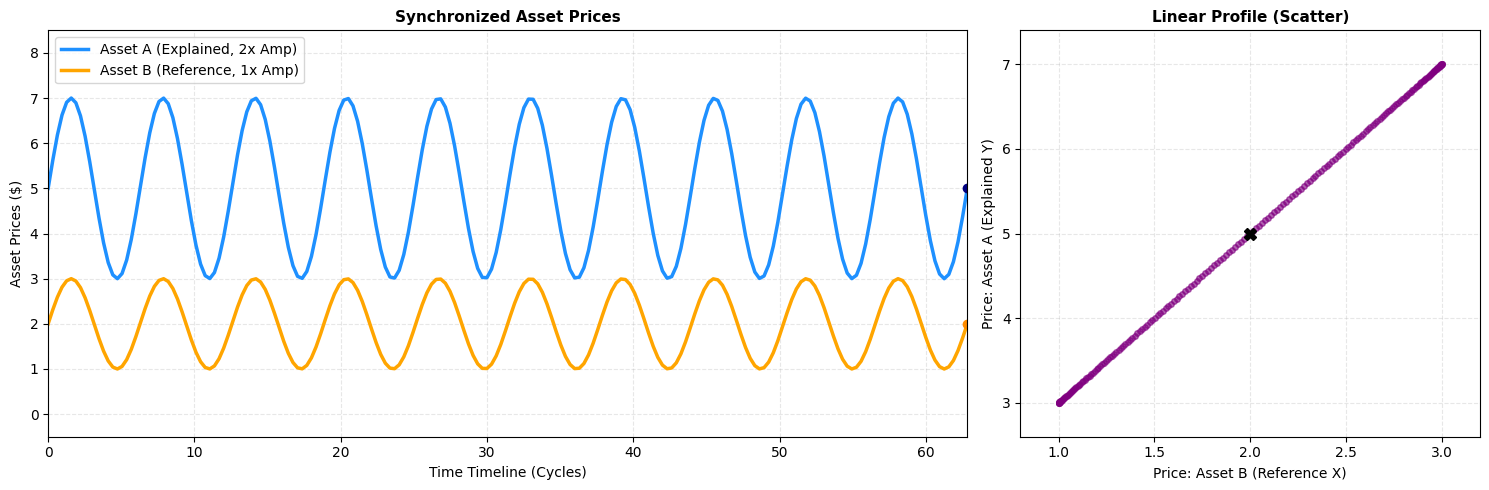

In [112]:
# Launch the pure linear sandbox
stream_pure_linear_scatter(total_frames=200)


# With Noise

In [113]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

def stream_noisy_linear_scatter(total_frames=200):
    """
    Split screen layout:
    2/3 left for synchronized noisy sine waves, 1/3 right for the structural scatter cloud.
    Demonstrates a linear link disrupted by Gaussian white noise.
    """
    np.random.seed(42) # Fixes the noise sequence so it remains persistent across loops
    max_x = 10 * 2 * np.pi
    x_space = np.linspace(0, max_x, total_frames)

    # 1. GENERATE NOISY SYNCHRONIZED SINE DATA
    # Asset B (Reference / Independent variable X) + custom noise
    asset_b_ref = 2.0 + 1.0 * np.sin(x_space) + np.random.normal(0, 0.08, size=total_frames)

    # Asset A (To be explained / Dependent variable Y)
    # Strictly twice Asset B + a constant shift of 1.0 + independent noise
    asset_a_exp = 2.0 * asset_b_ref + 1.0 + np.random.normal(0, 0.12, size=total_frames)

    # 2. PREPARE THE ASYMMETRICAL LAYOUT ONCE
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 5), gridspec_kw={'width_ratios': [2, 1]})

    # Left Panel Config (Time-Series Prices)
    ax1.set_xlim(0, max_x)
    ax1.set_ylim(-0.5, 8.5)
    ax1.set_title("Noisy Synchronized Asset Prices", fontsize=11, fontweight="bold")
    ax1.set_xlabel("Time Timeline (Cycles)")
    ax1.set_ylabel("Asset Prices ($)")
    ax1.grid(True, linestyle="--", alpha=0.3)

    line_a, = ax1.plot([], [], color="dodgerblue", linewidth=2, label="Asset A (Explained, 2x Amp)")
    line_b, = ax1.plot([], [], color="orange", linewidth=2, label="Asset B (Reference, 1x Amp)")
    tip_a, = ax1.plot([], [], color="navy", marker="o", markersize=5)
    tip_b, = ax1.plot([], [], color="darkorange", marker="o", markersize=5)
    ax1.legend(loc="upper left")

    # Right Panel Config (The Structural Scatter Cloud Space)
    ax2.set_xlim(min(asset_b_ref) - 0.2, max(asset_b_ref) + 0.2)
    ax2.set_ylim(min(asset_a_exp) - 0.4, max(asset_a_exp) + 0.4)
    ax2.set_title("Linear Dispersion Cloud (Scatter)", fontsize=11, fontweight="bold")
    ax2.set_xlabel("Price: Asset B (Reference X)")
    ax2.set_ylabel("Price: Asset A (Explained Y)")
    ax2.grid(True, linestyle="--", alpha=0.3)

    # Initialize empty dispersion layer
    scatter_dots, = ax2.plot([], [], color="purple", marker="o", linestyle="None", markersize=4, alpha=0.6)
    current_tip_dot, = ax2.plot([], [], color="black", marker="X", markersize=8)

    fig.tight_layout()

    # Real-time tracking vectors
    x_hist, a_hist, b_hist = [], [], []

    try:
        # 3. HIGH-SPEED ANIMATION LOOP
        for i in range(total_frames):
            cx = x_space[i]
            ca = asset_a_exp[i]
            cb = asset_b_ref[i]

            x_hist.append(cx)
            a_hist.append(ca)
            b_hist.append(cb)

            # Repaint Left Price Lines
            line_a.set_data(x_hist, a_hist)
            tip_a.set_data([cx], [ca])
            line_b.set_data(x_hist, b_hist)
            tip_b.set_data([cx], [cb])

            # Repaint Right Scatter Matrix (Mapping X=b_hist, Y=a_hist)
            scatter_dots.set_data(b_hist, a_hist)
            current_tip_dot.set_data([cb], [ca])

            clear_output(wait=True)
            display(fig)

        plt.close(fig)

    except KeyboardInterrupt:
        print("\n[INFO] Dashboard stopped safely by user.")
    finally:
        plt.close(fig)


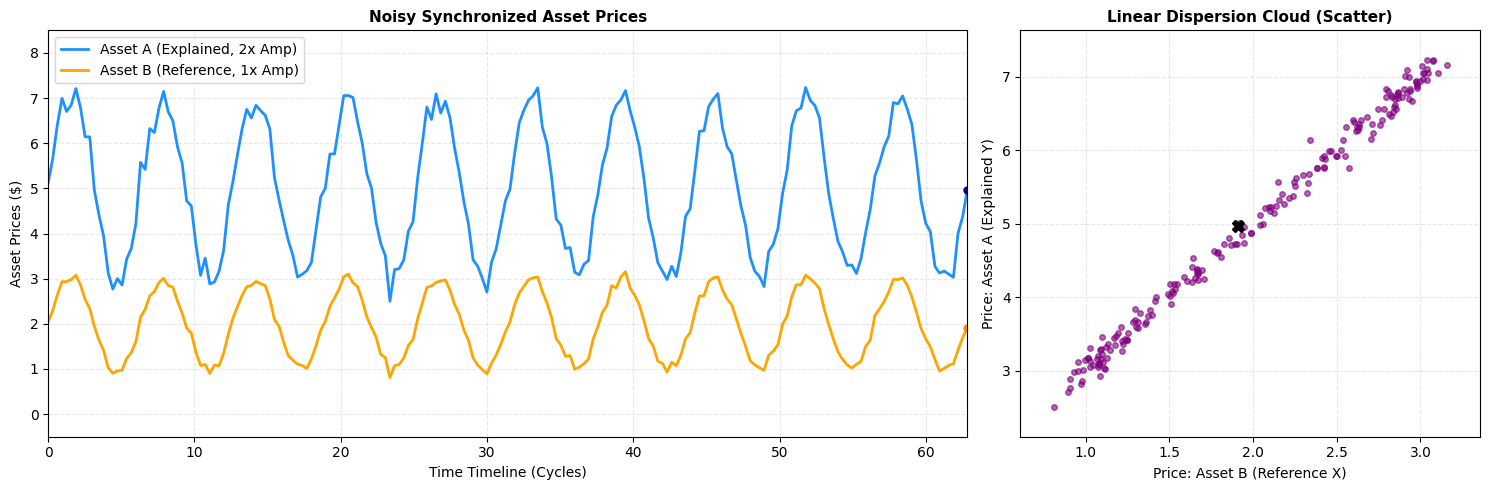

In [114]:
stream_noisy_linear_scatter(total_frames=200)


# Noise + Anomalies

In [115]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

def stream_anomalous_linear_scatter(total_frames=300):
    """
    Split screen layout:
    2/3 left for synchronized noisy sine waves with 4 injected price anomalies.
    1/3 right for the scatter plot showing outliers jumping out of the linear cloud.
    """
    np.random.seed(42)
    max_x = 15 * 2 * np.pi # Expanded time axis to spread out the 4 anomalies
    x_space = np.linspace(0, max_x, total_frames)

    # 1. GENERATE BASE NOISY SYNCHRONIZED DATA
    asset_b_ref = 2.0 + 1.0 * np.sin(x_space) + np.random.normal(0, 0.06, size=total_frames)
    asset_a_exp = 2.0 * asset_b_ref + 1.0 + np.random.normal(0, 0.08, size=total_frames)

    # 2. INJECT 4 MIXED ANOMALIES (SHOCKS) ON ASSET A
    for t in range(total_frames):
        # Anomaly 1: Asset A drops heavily (frames 45 to 75)
        if 45 <= t < 75:
            factor = np.sin(np.pi * (t - 45) / 30)
            asset_a_exp[t] -= 1.8 * factor
        # Anomaly 2: Asset A spikes heavily (frames 110 to 140)
        elif 110 <= t < 140:
            factor = np.sin(np.pi * (t - 110) / 30)
            asset_a_exp[t] += 1.8 * factor
        # Anomaly 3: Asset A drops heavily (frames 180 to 210)
        elif 180 <= t < 210:
            factor = np.sin(np.pi * (t - 180) / 30)
            asset_a_exp[t] -= 1.8 * factor
        # Anomaly 4: Asset A spikes heavily (frames 245 to 275)
        elif 245 <= t < 275:
            factor = np.sin(np.pi * (t - 245) / 30)
            asset_a_exp[t] += 1.8 * factor

    # 3. PREPARE THE ASYMMETRICAL LAYOUT ONCE
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 5), gridspec_kw={'width_ratios': [2, 1]})

    # Left Panel Config (Time-Series Prices)
    ax1.set_xlim(0, max_x)
    ax1.set_ylim(-1.5, 9.5) # Expanded vertical axis to accommodate the spikes
    ax1.set_title("Asset Price Evolution with 4 Structural Anomalies", fontsize=11, fontweight="bold")
    ax1.set_xlabel("Time Timeline (Cycles)")
    ax1.set_ylabel("Asset Prices ($)")
    ax1.grid(True, linestyle="--", alpha=0.3)

    line_a, = ax1.plot([], [], color="dodgerblue", linewidth=2, label="Asset A (Explained, 2x Amp)")
    line_b, = ax1.plot([], [], color="orange", linewidth=2, label="Asset B (Reference, 1x Amp)")
    tip_a, = ax1.plot([], [], color="navy", marker="o", markersize=5)
    tip_b, = ax1.plot([], [], color="darkorange", marker="o", markersize=5)
    ax1.legend(loc="upper left")

    # Right Panel Config (Scatter Space with Outliers)
    ax2.set_xlim(min(asset_b_ref) - 0.2, max(asset_b_ref) + 0.2)
    ax2.set_ylim(min(asset_a_exp) - 0.4, max(asset_a_exp) + 0.4)
    ax2.set_title("Scatter Correlation with Visible Outliers", fontsize=11, fontweight="bold")
    ax2.set_xlabel("Price: Asset B (Reference X)")
    ax2.set_ylabel("Price: Asset A (Explained Y)")
    ax2.grid(True, linestyle="--", alpha=0.3)

    scatter_dots, = ax2.plot([], [], color="purple", marker="o", linestyle="None", markersize=4, alpha=0.6)
    current_tip_dot, = ax2.plot([], [], color="black", marker="X", markersize=8)

    fig.tight_layout()

    # Real-time caching variables
    x_hist, a_hist, b_hist = [], [], []

    try:
        # 4. HIGH-SPEED ANIMATION LOOP
        for i in range(total_frames):
            cx = x_space[i]
            ca = asset_a_exp[i]
            cb = asset_b_ref[i]

            x_hist.append(cx)
            a_hist.append(ca)
            b_hist.append(cb)

            # Repaint Left Price Lines
            line_a.set_data(x_hist, a_hist)
            tip_a.set_data([cx], [ca])
            line_b.set_data(x_hist, b_hist)
            tip_b.set_data([cx], [cb])

            # Repaint Right Scatter Plot Matrix
            scatter_dots.set_data(b_hist, a_hist)
            current_tip_dot.set_data([cb], [ca])

            clear_output(wait=True)
            display(fig)

        plt.close(fig)

    except KeyboardInterrupt:
        print("\n[INFO] Dashboard stopped safely by user.")
    finally:
        plt.close(fig)


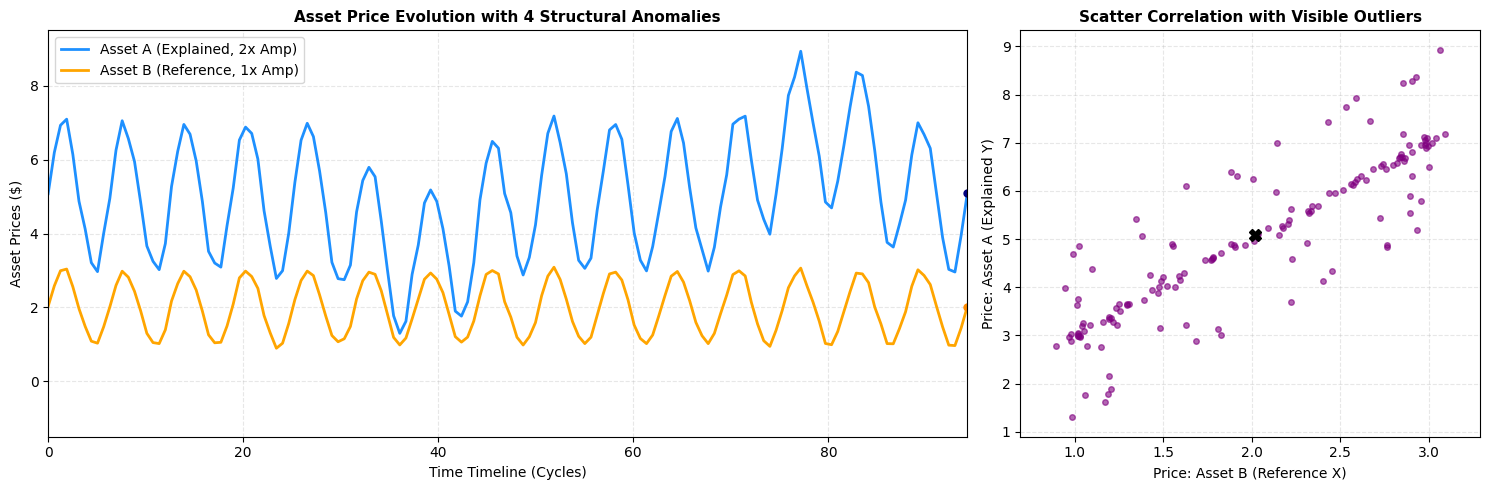

In [117]:
stream_anomalous_linear_scatter(total_frames=150)


# Regime Changes 

In [118]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

def stream_regime_change_scatter(total_frames=150):
    """
    Split screen layout:
    2/3 left for 3 synchronized market regimes (Stable -> USD Crash Trend -> Stable).
    1/3 right for the scatter plot showcasing the cloud expanding along its linear axis.
    Fixed the gridspec_kw [2, 1] syntax error.
    """
    np.random.seed(42)
    max_x = 15 * 2 * np.pi
    x_space = np.linspace(0, max_x, total_frames)

    start_trend = int(total_frames * 0.35)
    end_trend = int(total_frames * 0.65)

    asset_b_ref = np.zeros(total_frames)
    asset_a_exp = np.zeros(total_frames)

    baseline_b = 0.5
    baseline_a = 2.0
    amplitude = 0.4

    # Macro trends parameters matching a perfect 1:2 Hedge Ratio
    slope_b = 3.0 / (end_trend - start_trend) # Asset B climbs by 3.0$
    slope_a = 6.0 / (end_trend - start_trend) # Asset A climbs by 6.0$

    # 1. GENERATE THE 3 REGIMES DATA MATRIX
    for t in range(total_frames):
        x = x_space[t]
        noise_b = np.random.normal(0, 0.04)
        noise_a = np.random.normal(0, 0.05)

        # --- REGIME 1: Initial Stable Base ---
        if t < start_trend:
            asset_b_ref[t] = baseline_b + amplitude * np.sin(x) + noise_b
            asset_a_exp[t] = baseline_a + (2.0 * amplitude * np.sin(x)) + noise_a

        # --- REGIME 2: Synchronized Macro Trend Breakout ---
        elif start_trend <= t < end_trend:
            steps = t - start_trend
            shift_b = slope_b * steps
            shift_a = slope_a * steps

            asset_b_ref[t] = baseline_b + shift_b + amplitude * np.sin(x) + noise_b
            asset_a_exp[t] = baseline_a + shift_a + (2.0 * amplitude * np.sin(x)) + noise_a

        # --- REGIME 3: New Elevated Stable Plateau ---
        else:
            asset_b_ref[t] = baseline_b + 3.0 + amplitude * np.sin(x) + noise_b
            asset_a_exp[t] = baseline_a + 6.0 + (2.0 * amplitude * np.sin(x)) + noise_a

    # 2. PREPARE THE INTERFACE VIEWPORT ONCE
    # FIXED: The [2, 1] width allocation is now properly written after the colon
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 5), gridspec_kw={'width_ratios': [2, 1]})

    # Configure Left Panel (Prices)
    ax1.set_xlim(0, max_x)
    ax1.set_ylim(-0.5, 9.5)
    ax1.set_title("Asset Prices: 3 Synchronized Regimes", fontsize=11, fontweight="bold")
    ax1.set_xlabel("Time Timeline (Cycles)")
    ax1.set_ylabel("Asset Prices ($)")
    ax1.grid(True, linestyle="--", alpha=0.3)

    line_a, = ax1.plot([], [], color="dodgerblue", linewidth=2, label="Asset A (Explained, 2x Beta)")
    line_b, = ax1.plot([], [], color="orange", linewidth=2, label="Asset B (Reference, 1x Beta)")
    tip_a, = ax1.plot([], [], color="navy", marker="o", markersize=5)
    tip_b, = ax1.plot([], [], color="darkorange", marker="o", markersize=5)
    ax1.legend(loc="upper left")

    # Configure Right Panel (The Sliding Scatter Space)
    ax2.set_xlim(min(asset_b_ref) - 0.2, max(asset_b_ref) + 0.2)
    ax2.set_ylim(min(asset_a_exp) - 0.4, max(asset_a_exp) + 0.4)
    ax2.set_title("Scatter Space: Cloud Migration Along Linear Axis", fontsize=11, fontweight="bold")
    ax2.set_xlabel("Price: Asset B (Reference X)")
    ax2.set_ylabel("Price: Asset A (Explained Y)")
    ax2.grid(True, linestyle="--", alpha=0.3)

    scatter_dots, = ax2.plot([], [], color="purple", marker="o", linestyle="None", markersize=4, alpha=0.5)
    current_tip_dot, = ax2.plot([], [], color="black", marker="X", markersize=8)

    fig.tight_layout()
    x_hist, a_hist, b_hist = [], [], []

    try:
        # 3. FAST RENDERING ANIMATION LOOP
        for i in range(total_frames):
            cx = x_space[i]
            ca = asset_a_exp[i]
            cb = asset_b_ref[i]

            x_hist.append(cx)
            a_hist.append(ca)
            b_hist.append(cb)

            # Repaint Left Price Handles
            line_a.set_data(x_hist, a_hist)
            tip_a.set_data([cx], [ca])
            line_b.set_data(x_hist, b_hist)
            tip_b.set_data([cx], [cb])

            # Repaint Right Scatter Handles
            scatter_dots.set_data(b_hist, a_hist)
            current_tip_dot.set_data([cb], [ca])

            clear_output(wait=True)
            display(fig)

        plt.close(fig)

    except KeyboardInterrupt:
        print("\n[INFO] Dashboard stopped safely by user.")
    finally:
        plt.close(fig)


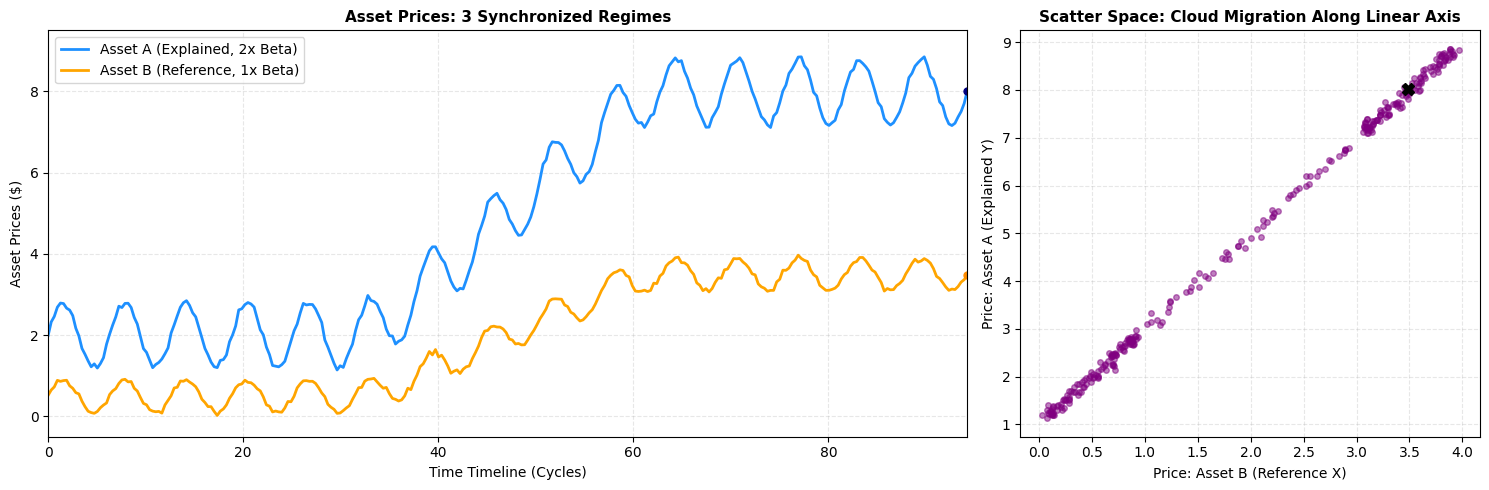

In [119]:
stream_regime_change_scatter(total_frames=300)


# Hedge Ratio Changes

In [120]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

def stream_beta_regime_change_scatter(total_frames=300):
    """
    Split screen layout:
    2/3 left for 3 market regimes where Asset B (orange) catches up to Asset A (blue).
    1/3 right for the scatter plot showcasing the transition from a steep slope (Beta=2)
    to a flatter slope (Beta=1) in the final regime.
    """
    np.random.seed(42)
    max_x = 15 * 2 * np.pi
    x_space = np.linspace(0, max_x, total_frames)

    start_trend = int(total_frames * 0.35)
    end_trend = int(total_frames * 0.65)

    asset_b_ref = np.zeros(total_frames)
    asset_a_exp = np.zeros(total_frames)

    # Initial states (Regime 1)
    baseline_b = 1.0
    baseline_a = 3.0 # Asset A is higher and has twice the amplitude of B
    amplitude_b = 0.3
    amplitude_a = 0.6 # Beta = 2.0 initially

    # Trend parameters: B climbs aggressively to catch up, A climbs slowly
    # Asset B climbs from 1.0 to 8.0 (+7.0$)
    # Asset A climbs from 3.0 to 8.0 (+5.0$)
    slope_b = 7.0 / (end_trend - start_trend)
    slope_a = 5.0 / (end_trend - start_trend)

    # 1. GENERATE THE ASYMMETRIC WEIGHT MATRIX DATA
    for t in range(total_frames):
        x = x_space[t]
        noise_b = np.random.normal(0, 0.04)
        noise_a = np.random.normal(0, 0.05)

        # --- REGIME 1: Initial Steep Slope (Beta = 2.0) ---
        if t < start_trend:
            asset_b_ref[t] = baseline_b + amplitude_b * np.sin(x) + noise_b
            asset_a_exp[t] = baseline_a + amplitude_a * np.sin(x) + noise_a

        # --- REGIME 2: The Catch-Up Phase (Transition) ---
        elif start_trend <= t < end_trend:
            steps = t - start_trend
            shift_b = slope_b * steps
            shift_a = slope_a * steps

            # Interpolate amplitudes from (0.3 -> 0.5) for B and (0.6 -> 0.5) for A
            progress = steps / (end_trend - start_trend)
            current_amp_b = 0.3 + (0.5 - 0.3) * progress
            current_amp_a = 0.6 + (0.5 - 0.6) * progress

            asset_b_ref[t] = baseline_b + shift_b + current_amp_b * np.sin(x) + noise_b
            asset_a_exp[t] = baseline_a + shift_a + current_amp_a * np.sin(x) + noise_a

        # --- REGIME 3: Final Flat Slope (Beta = 1.0 - Caught Up) ---
        else:
            # Both assets are now equalized at baseline 8.0$ and amplitude 0.5
            asset_b_ref[t] = 8.0 + 0.5 * np.sin(x) + noise_b
            asset_a_exp[t] = 8.0 + 0.5 * np.sin(x) + noise_a

    # 2. PREPARE THE VIEWPORT CANVAS (Strict fixed [2, 1] widths)
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 5), gridspec_kw={'width_ratios': [2, 1]})

    # Left Panel Config (Prices)
    ax1.set_xlim(0, max_x)
    ax1.set_ylim(-0.5, 10.5)
    ax1.set_title("Asset Prices: Asset B Catching Up to Asset A", fontsize=11, fontweight="bold")
    ax1.set_xlabel("Time Timeline (Cycles)")
    ax1.set_ylabel("Asset Prices ($)")
    ax1.grid(True, linestyle="--", alpha=0.3)

    line_a, = ax1.plot([], [], color="dodgerblue", linewidth=2, label="Asset A (Explained)")
    line_b, = ax1.plot([], [], color="orange", linewidth=2, label="Asset B (Reference)")
    tip_a, = ax1.plot([], [], color="navy", marker="o", markersize=5)
    tip_b, = ax1.plot([], [], color="darkorange", marker="o", markersize=5)
    ax1.legend(loc="upper left")

    # Configure Right Panel (The Slope Changing Scatter Space)
    ax2.set_xlim(min(asset_b_ref) - 0.2, max(asset_b_ref) + 0.2)
    ax2.set_ylim(min(asset_a_exp) - 0.4, max(asset_a_exp) + 0.4)
    ax2.set_title("Scatter Space: Slope Regime Shift (Beta 2 -> Beta 1)", fontsize=11, fontweight="bold")
    ax2.set_xlabel("Price: Asset B (Reference X)")
    ax2.set_ylabel("Price: Asset A (Explained Y)")
    ax2.grid(True, linestyle="--", alpha=0.3)

    scatter_dots, = ax2.plot([], [], color="purple", marker="o", linestyle="None", markersize=4, alpha=0.5)
    current_tip_dot, = ax2.plot([], [], color="black", marker="X", markersize=8)

    fig.tight_layout()
    x_hist, a_hist, b_hist = [], [], []

    try:
        # 3. INTERACTIVE RENDERING ANIMATION LOOP
        for i in range(total_frames):
            cx = x_space[i]
            ca = asset_a_exp[i]
            cb = asset_b_ref[i]

            x_hist.append(cx)
            a_hist.append(ca)
            b_hist.append(cb)

            # Update Left Price Stream Curves
            line_a.set_data(x_hist, a_hist)
            tip_a.set_data([cx], [ca])
            line_b.set_data(x_hist, b_hist)
            tip_b.set_data([cx], [cb])

            # Update Right Scatter Cloud Matrix
            scatter_dots.set_data(b_hist, a_hist)
            current_tip_dot.set_data([cb], [ca])

            clear_output(wait=True)
            display(fig)

        plt.close(fig)

    except KeyboardInterrupt:
        print("\n[INFO] Dashboard stopped safely by user.")
    finally:
        plt.close(fig)


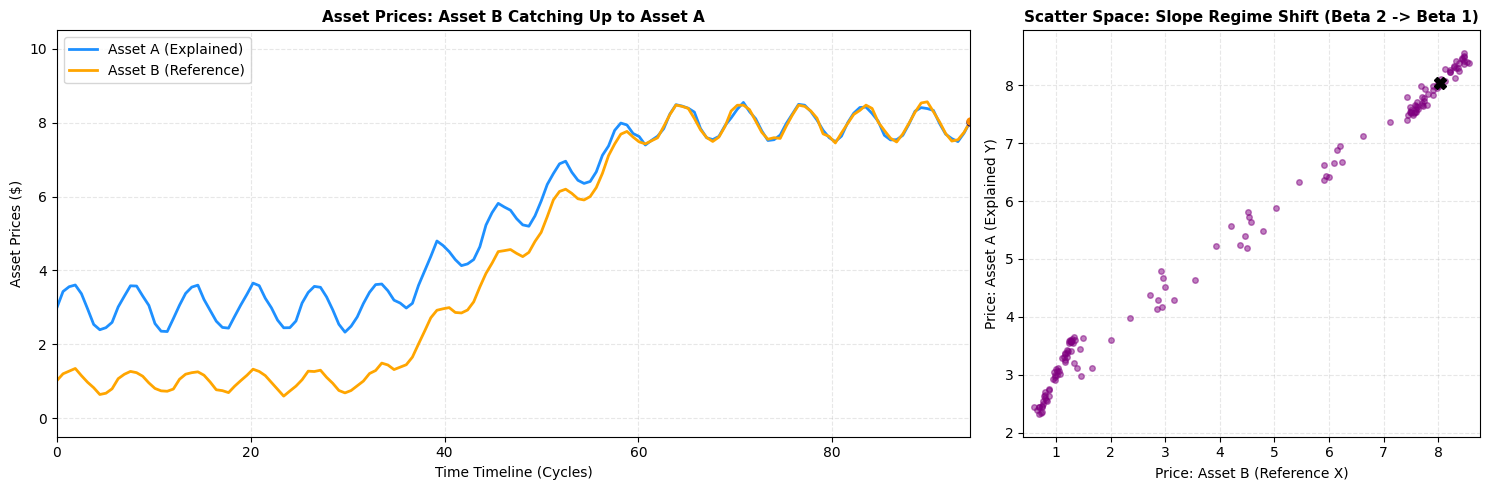

In [121]:
stream_beta_regime_change_scatter(total_frames=150)


# Intercept/Hedge Ratio changes

In [122]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

def stream_accentuated_slopes_with_regression(total_frames=150):
    """
    Split screen layout:
    2/3 left for 3 market regimes where Asset B (orange) rises to lock an exact 1.0$ gap below Asset A (blue).
    1/3 right for the scatter plot showcasing a heavy slope shift.
    Bakes two theoretical regression lines at the final frame for analytical comparison.
    """
    np.random.seed(42)
    max_x = 15 * 2 * np.pi
    x_space = np.linspace(0, max_x, total_frames)

    start_trend = int(total_frames * 0.35)
    end_trend = int(total_frames * 0.65)

    asset_b_ref = np.zeros(total_frames)
    asset_a_exp = np.zeros(total_frames)

    # ACCENTUATED BETA COEFFICIENTS
    beta_steep = 3.0
    beta_flat = 0.5

    # Initial parameters (Regime 1)
    baseline_b = 0.8
    baseline_a = 3.4
    amp_b_1 = 0.2
    amp_a_1 = amp_b_1 * beta_steep

    # Final parameters (Regime 3)
    final_baseline_b = 6.0
    final_baseline_a = 7.0 # Strict permanent 1.0$ gap
    amp_b_3 = 0.8
    amp_a_3 = amp_b_3 * beta_flat

    # Trend parameters for the baseline climb
    slope_b = (final_baseline_b - baseline_b) / (end_trend - start_trend)
    slope_a = (final_baseline_a - baseline_a) / (end_trend - start_trend)

    # 1. GENERATE THE DATA VECTORS
    for t in range(total_frames):
        x = x_space[t]
        noise_b = np.random.normal(0, 0.03)
        noise_a = np.random.normal(0, 0.03)

        # --- REGIME 1: Initial Steep Slope (Beta = 3.0) ---
        if t < start_trend:
            asset_b_ref[t] = baseline_b + amp_b_1 * np.sin(x) + noise_b
            asset_a_exp[t] = baseline_a + amp_a_1 * np.sin(x) + noise_a

        # --- REGIME 2: Asymmetric Catch-up Transition ---
        elif start_trend <= t < end_trend:
            steps = t - start_trend
            progress = steps / (end_trend - start_trend)

            current_base_b = baseline_b + slope_b * steps
            current_base_a = baseline_a + slope_a * steps

            current_amp_b = amp_b_1 + (amp_b_3 - amp_b_1) * progress
            current_amp_a = amp_a_1 + (amp_a_3 - amp_a_1) * progress

            asset_b_ref[t] = current_base_b + current_amp_b * np.sin(x) + noise_b
            asset_a_exp[t] = current_base_a + current_amp_a * np.sin(x) + noise_a

        # --- REGIME 3: New Balanced Regime (Beta = 0.5, Constant 1.0$ Intercept Gap) ---
        else:
            asset_b_ref[t] = final_baseline_b + amp_b_3 * np.sin(x) + noise_b
            asset_a_exp[t] = final_baseline_a + amp_a_3 * np.sin(x) + noise_a

    # 2. PREPARE THE VIEWPORT CANVAS (Strict 2/3 vs 1/3 horizontal allocation)
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), gridspec_kw={'width_ratios': [2, 1]})

    # Configure Left Panel (Prices Timeline)
    ax1.set_xlim(0, max_x)
    ax1.set_ylim(-0.5, 9.5)
    ax1.set_title("Forex Prices: Asset B Catching Up with an Exact 1.0$ Gap", fontsize=11, fontweight="bold")
    ax1.set_xlabel("Time Timeline (Cycles)")
    ax1.set_ylabel("Asset Prices ($)")
    ax1.grid(True, linestyle="--", alpha=0.3)

    line_a, = ax1.plot([], [], color="dodgerblue", linewidth=2, label="Asset A (Explained)")
    line_b, = ax1.plot([], [], color="orange", linewidth=2, label="Asset B (Reference)")
    tip_a, = ax1.plot([], [], color="navy", marker="o", markersize=5)
    tip_b, = ax1.plot([], [], color="darkorange", marker="o", markersize=5)
    ax1.legend(loc="upper left")

    # Configure Right Panel (Scatter plot with fixed equal aspect to see real geometric angles)
    ax2.set_xlim(0.0, 8.5)
    ax2.set_ylim(0.0, 8.5)
    ax2.set_aspect('equal')
    ax2.set_title("Scatter Space: Slope Comparison & Regression Lines", fontsize=11, fontweight="bold")
    ax2.set_xlabel("Price: Asset B (Reference X)")
    ax2.set_ylabel("Price: Asset A (Explained Y)")
    ax2.grid(True, linestyle="--", alpha=0.3)

    scatter_dots, = ax2.plot([], [], color="purple", marker="o", linestyle="None", markersize=4, alpha=0.5)
    current_tip_dot, = ax2.plot([], [], color="black", marker="X", markersize=8)

    # Placeholders for our theoretical lines (hidden at launch)
    reg_line_1, = ax2.plot([], [], color="purple", linewidth=2, linestyle="-", alpha=0.8, label="Initial Reg (Beta=3.0)")
    reg_line_2, = ax2.plot([], [], color="green", linewidth=2, linestyle="-", alpha=0.8, label="Final Reg (Beta=0.5)")

    fig.tight_layout()
    x_hist, a_hist, b_hist = [], [], []

    try:
        # 3. INTERACTIVE RENDERING ANIMATION LOOP
        for i in range(total_frames):
            cx = x_space[i]
            ca = asset_a_exp[i]
            cb = asset_b_ref[i]

            x_hist.append(cx)
            a_hist.append(ca)
            b_hist.append(cb)

            # Repaint Left Price Lines
            line_a.set_data(x_hist, a_hist)
            tip_a.set_data([cx], [ca])
            line_b.set_data(x_hist, b_hist)
            tip_b.set_data([cx], [cb])

            # Repaint Right Scatter Matrix
            scatter_dots.set_data(b_hist, a_hist)
            current_tip_dot.set_data([cb], [ca])

            # FIX/FEATURE: Bake the theoretical regression lines ONLY on the very last frame for comparison
            if i == total_frames - 1:
                # Line 1 evaluation space (around the initial cluster)
                x_fit_1 = np.linspace(0.2, 1.8, 10)
                y_fit_1 = beta_steep * x_fit_1 + (baseline_a - beta_steep * baseline_b)
                reg_line_1.set_data(x_fit_1, y_fit_1)

                # Line 2 evaluation space (around the final cluster)
                x_fit_2 = np.linspace(4.5, 7.8, 10)
                y_fit_2 = beta_flat * x_fit_2 + 4.0 # Yields exactly 7.0 when X=6.0 (Intercept model)
                reg_line_2.set_data(x_fit_2, y_fit_2)

                # Display the legend to document the lines context
                ax2.legend(loc="upper left", fontsize=8)

            clear_output(wait=True)
            display(fig)

        plt.close(fig)

    except KeyboardInterrupt:
        print("\n[INFO] Dashboard stopped safely by user.")
    finally:
        plt.close(fig)


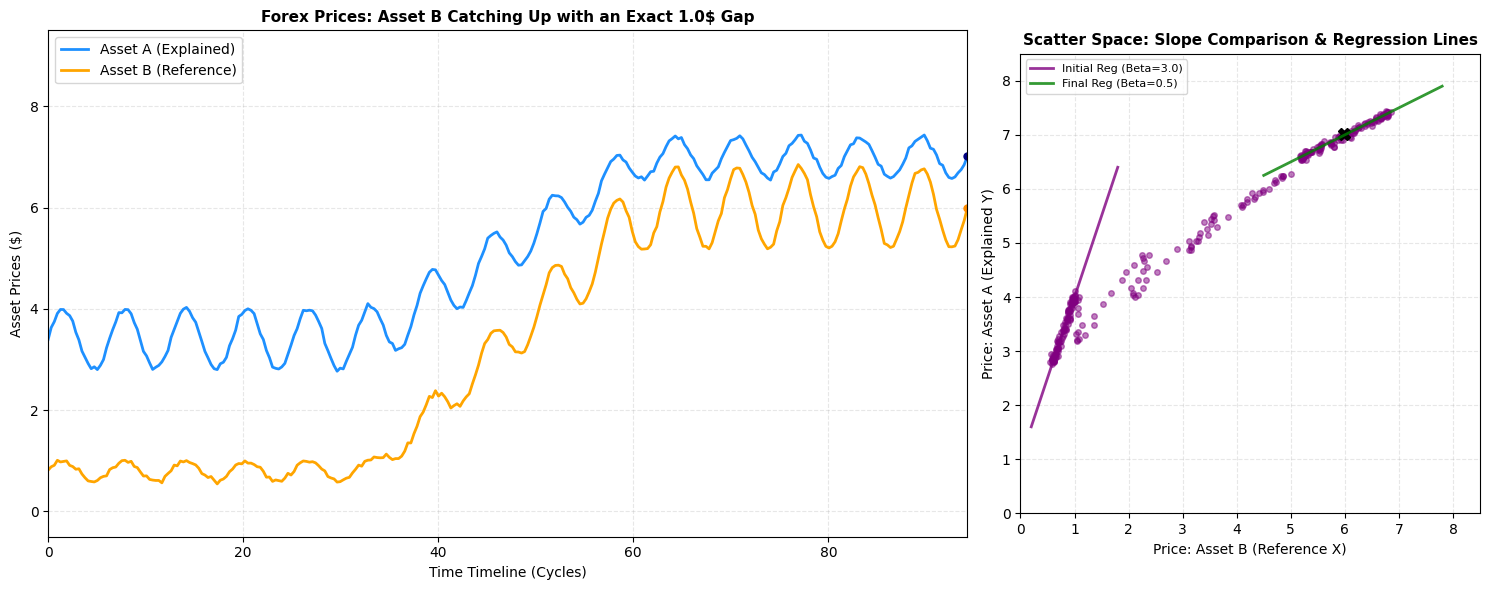

In [123]:
stream_accentuated_slopes_with_regression(total_frames=300)


# Linear Regression (no regime change)

In [124]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

def stream_high_noise_rolling_scatter(total_frames=200):
    """
    Split screen layout:
    Left Panel (2/3 width): Highly volatile twin prices timeline.
    Right Panel (1/3 width): Wide scatter cloud and dynamic OLS line
    calculated inside a 30-point rolling window with high error dispersion.
    """
    np.random.seed(42)
    max_x = 10 * 2 * np.pi
    x_space = np.linspace(0, max_x, total_frames)
    window_size = 30

    # 1. GENERATE HIGHLY NOISY SYNCHRONIZED MARKET DATA
    # Increased noise standard deviation significantly to create high error dispersion
    asset_b_ref = 2.5 + 0.8 * np.sin(x_space) + np.random.normal(0, 0.25, size=total_frames)
    # Asset A (Explained Y): Beta = 2.0, Intercept = 1.0$ + heavy independent noise
    asset_a_exp = 2.0 * asset_b_ref + 1.0 + np.random.normal(0, 0.40, size=total_frames)

    # 2. PREPARE THE VIEWPORT CANVAS ONCE
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), gridspec_kw={'width_ratios': [2, 1]})

    # Left Panel Layout (Prices Timeline)
    ax1.set_xlim(0, max_x)
    ax1.set_ylim(-1.5, 11.5) # Expanded bounds to prevent clipping from heavy noise
    ax1.set_title("Highly Volatile Asset Prices Timeline", fontsize=11, fontweight="bold")
    ax1.set_xlabel("Time Timeline (Cycles)")
    ax1.set_ylabel("Asset Prices ($)")
    ax1.grid(True, linestyle="--", alpha=0.3)

    line_a, = ax1.plot([], [], color="dodgerblue", linewidth=1.5, label="Asset A (Explained)")
    line_b, = ax1.plot([], [], color="orange", linewidth=1.5, label="Asset B (Reference)")
    tip_a, = ax1.plot([], [], color="navy", marker="o", markersize=5)
    tip_b, = ax1.plot([], [], color="darkorange", marker="o", markersize=5)
    ax1.legend(loc="upper left")

    # Right Panel Layout (Wide Scatter Cloud)
    ax2.set_xlim(0.5, 4.5)
    ax2.set_ylim(1.5, 11.5)
    ax2.set_aspect('equal')
    ax2.set_title(f"Scatter Space: Wide {window_size}-Point Cloud", fontsize=11, fontweight="bold")
    ax2.set_xlabel("Price: Asset B (Reference X)")
    ax2.set_ylabel("Price: Asset A (Explained Y)")
    ax2.grid(True, linestyle="--", alpha=0.3)

    # Wide rolling scatter points layer
    scatter_dots, = ax2.plot([], [], color="purple", marker="o", linestyle="None", markersize=5, alpha=0.6)
    current_tip_dot, = ax2.plot([], [], color="black", marker="X", markersize=8)

    # Volatile rolling OLS line layer
    rolling_reg_line, = ax2.plot([], [], color="crimson", linewidth=2.5, label="Rolling OLS")
    ax2.legend(loc="upper left")

    fig.tight_layout()
    x_hist, a_hist, b_hist = [], [], []

    try:
        # 3. INTERACTIVE RENDERING LOOP
        for i in range(total_frames):
            cx = x_space[i]
            ca = asset_a_exp[i]
            cb = asset_b_ref[i]

            x_hist.append(cx)
            a_hist.append(ca)
            b_hist.append(cb)

            # Extract current moving rolling window
            slice_start = max(0, i - window_size + 1)
            x_window = np.array(b_hist[slice_start:i+1])
            y_window = np.array(a_hist[slice_start:i+1])

            # 4. MATH ENGINE COMPILATION
            if len(x_window) >= 2:
                # Rolling OLS algorithm calculation
                covariance_matrix = np.cov(x_window, y_window)
                variance_x = np.var(x_window, ddof=1)

                if variance_x > 0:
                    beta_rolling = covariance_matrix[0, 1] / variance_x
                    alpha_rolling = np.mean(y_window) - beta_rolling * np.mean(x_window)

                    # Project line segment over the current scatter viewport bounds
                    x_fit = np.linspace(0.8, 4.2, 10)
                    y_fit = beta_rolling * x_fit + alpha_rolling
                    rolling_reg_line.set_data(x_fit, y_fit)

            # Repaint Left panel history vectors
            line_a.set_data(x_hist, a_hist)
            tip_a.set_data([cx], [ca])
            line_b.set_data(x_hist, b_hist)
            tip_b.set_data([cx], [cb])

            # Repaint Right panel scatter (The moving wide cloud cluster)
            scatter_dots.set_data(x_window, y_window)
            current_tip_dot.set_data([cb], [ca])

            clear_output(wait=True)
            display(fig)

        plt.close(fig)

    except KeyboardInterrupt:
        print("\n[INFO] Rolling dashboard stopped safely.")
    finally:
        plt.close(fig)


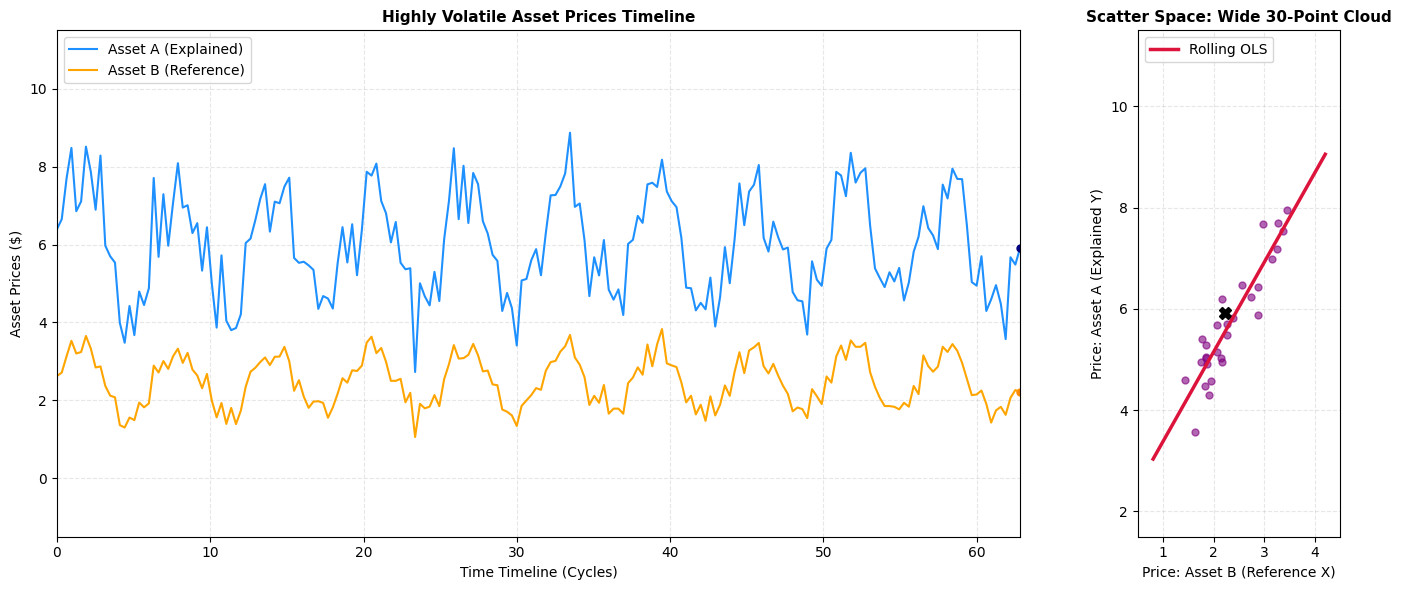

In [125]:
stream_high_noise_rolling_scatter(total_frames=200)


# Various rolling windows

In [126]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

def stream_multi_window_rolling_scatter(total_frames=250):
    """
    Advanced multi-panel analytics layout with correct OLS broadcasting logic.
    Top Row: Volatile price timeline (Asset A vs Asset B).
    Bottom Row: 3 parallel scatter plots tracking 3 different rolling window sizes (5, 30, 100).
    FIXED: Resolved numpy broadcasting shape error and forced strict 1:1 square aspects.
    """
    np.random.seed(42)
    max_x = 10 * 2 * np.pi
    x_space = np.linspace(0, max_x, total_frames)

    # Explicit definition of the 3 rolling windows sizes
    windows = [5, 30, 100]

    # 1. GENERATE VOLATILE STABLE REGIME DATA
    asset_b_ref = 2.5 + 0.8 * np.sin(x_space) + np.random.normal(0, 0.22, size=total_frames)
    asset_a_exp = 2.0 * asset_b_ref + 1.0 + np.random.normal(0, 0.35, size=total_frames)

    # 2. CREATE THE GRID ARCHITECTURE WITH REDUCED GENERAL SIZE (Divided by 2)
    fig = plt.figure(figsize=(12, 7.5))

    # Top Panel: Full-width spanning the 3 upper columns blocks
    ax_time = plt.subplot2grid((2, 3), (0, 0), colspan=3)
    ax_time.set_xlim(0, max_x)
    ax_time.set_ylim(-1.0, 11.0)
    ax_time.set_title("Volatile Asset Prices Timeline", fontsize=9, fontweight="bold")
    ax_time.set_ylabel("Prices ($)", fontsize=8)
    ax_time.tick_params(axis='both', labelsize=7)
    ax_time.grid(True, linestyle="--", alpha=0.3)

    line_a, = ax_time.plot([], [], color="dodgerblue", linewidth=1.2, label="Asset A")
    line_b, = ax_time.plot([], [], color="orange", linewidth=1.2, label="Asset B")
    tip_a, = ax_time.plot([], [], color="navy", marker="o", markersize=4)
    tip_b, = ax_time.plot([], [], color="darkorange", marker="o", markersize=4)
    ax_time.legend(loc="upper left", fontsize=7)

    # Bottom Row: 3 Independent Scatter Plot Axes
    ax_scatters = []
    scatter_dots_layers = []
    tip_dots_layers = []
    reg_lines_layers = []

    for idx, w_size in enumerate(windows):
        ax = plt.subplot2grid((2, 3), (1, idx))
        ax.set_xlim(0.5, 4.5)
        ax.set_ylim(1.5, 11.5)

        # FIX 1: Strict square aspect ratio for the plot box itself
        ax.set_box_aspect(1)

        ax.set_title(f"Window = {w_size}p", fontsize=8, fontweight="bold")
        ax.set_xlabel("Price B (X)", fontsize=7)
        if idx == 0:
            ax.set_ylabel("Price A (Y)", fontsize=7)
        ax.tick_params(axis='both', labelsize=6)
        ax.grid(True, linestyle="--", alpha=0.3)

        # Instantiate active graphical layers
        dots, = ax.plot([], [], color="purple", marker="o", linestyle="None", markersize=3, alpha=0.5)
        tip_dot, = ax.plot([], [], color="black", marker="X", markersize=5)
        reg_line, = ax.plot([], [], color="crimson", linewidth=1.8)

        ax_scatters.append(ax)
        scatter_dots_layers.append(dots)
        tip_dots_layers.append(tip_dot)
        reg_lines_layers.append(reg_line)

    fig.tight_layout()
    x_hist, a_hist, b_hist = [], [], []

    try:
        # 3. INTERACTIVE ANIMATION RUN
        for i in range(total_frames):
            cx = x_space[i]
            ca = asset_a_exp[i]
            cb = asset_b_ref[i]

            x_hist.append(cx)
            a_hist.append(ca)
            b_hist.append(cb)

            # Update Top Timeline
            line_a.set_data(x_hist, a_hist)
            tip_a.set_data([cx], [ca])
            line_b.set_data(x_hist, b_hist)
            tip_b.set_data([cx], [cb])

            # Update the 3 scatter spaces
            for idx, w_size in enumerate(windows):
                slice_start = max(0, i - w_size + 1)
                x_window = np.array(b_hist[slice_start:i+1])
                y_window = np.array(a_hist[slice_start:i+1])

                # Compute specific local OLS regression line
                if len(x_window) >= 2:
                    covariance_matrix = np.cov(x_window, y_window)
                    variance_x = np.var(x_window, ddof=1)

                    if variance_x > 0:
                        # FIX 2: Extract scalar covariance element [0, 1] to avoid shape broadcasting mismatch
                        xy_covariance = covariance_matrix[0, 1]
                        beta_rolling = xy_covariance / variance_x
                        alpha_rolling = np.mean(y_window) - beta_rolling * np.mean(x_window)

                        x_fit = np.linspace(0.8, 4.2, 10)
                        y_fit = beta_rolling * x_fit + alpha_rolling
                        reg_lines_layers[idx].set_data(x_fit, y_fit)

                # Update scatter markers and caterpillar shapes
                scatter_dots_layers[idx].set_data(x_window, y_window)
                tip_dots_layers[idx].set_data([cb], [ca])

            clear_output(wait=True)
            display(fig)

        plt.close(fig)

    except KeyboardInterrupt:
        print("\n[INFO] Dashboard stopped safely.")
    finally:
        plt.close(fig)


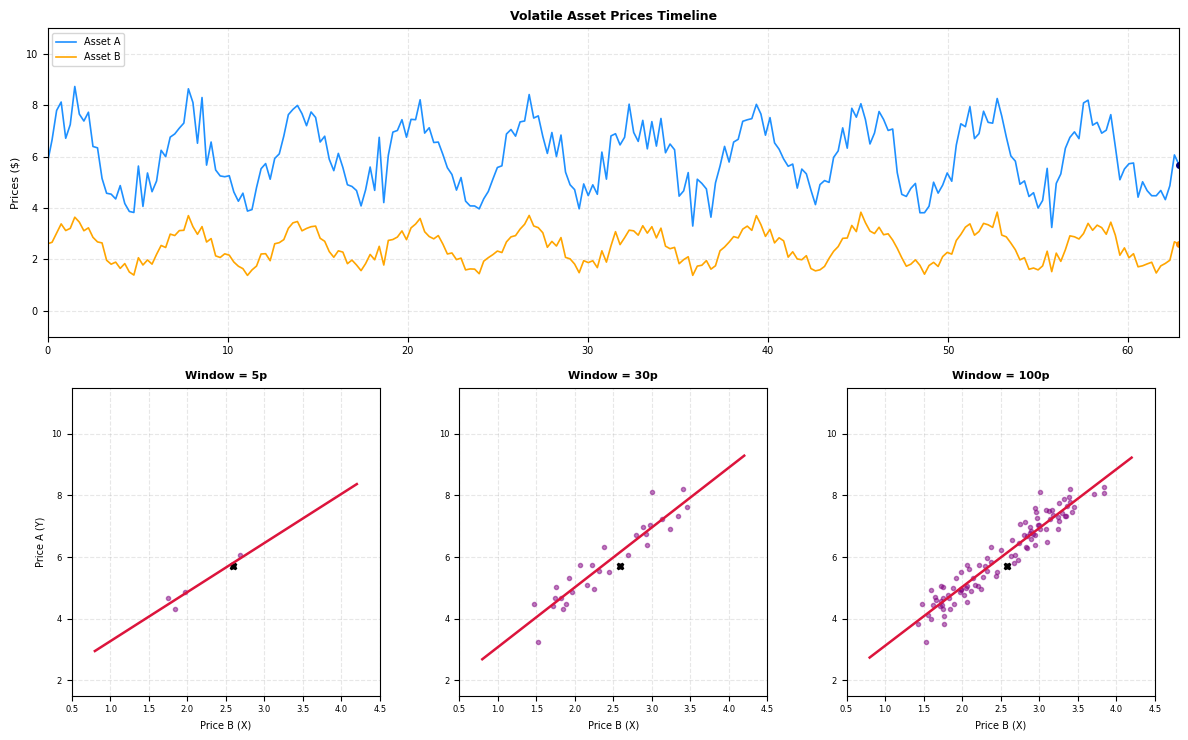

In [127]:
stream_multi_window_rolling_scatter(total_frames=250)


# with regime change

In [128]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

def stream_multi_window_regime_changes(total_frames=350):
    """
    Advanced multi-panel analytics layout.
    Top Row: 3 market regimes where Asset B (orange) rises to lock an exact 1.0$ gap below Asset A (blue).
    Bottom Row: 3 parallel square scatter plots tracking 3 different rolling window sizes (5, 30, 100).
    Demonstrates the structural lag and deformation of long-memory indicators during regime shifts.
    """
    np.random.seed(42)
    max_x = 15 * 2 * np.pi
    x_space = np.linspace(0, max_x, total_frames)

    start_trend = int(total_frames * 0.35)
    end_trend = int(total_frames * 0.65)
    windows = [5, 30, 100]

    asset_b_ref = np.zeros(total_frames)
    asset_a_exp = np.zeros(total_frames)

    # ACCENTUATED BETA COEFFICIENTS
    beta_steep = 3.0 # Regime 1 slope
    beta_flat = 0.5  # Regime 3 slope

    # Initial parameters (Regime 1)
    baseline_b = 0.8
    baseline_a = 3.4
    amp_b_1 = 0.2
    amp_a_1 = amp_b_1 * beta_steep

    # Final parameters (Regime 3)
    final_baseline_b = 6.0
    final_baseline_a = 7.0 # Strict permanent 1.0$ gap
    amp_b_3 = 0.8
    amp_a_3 = amp_b_3 * beta_flat

    # Trend parameters for the baseline climb
    slope_b = (final_baseline_b - baseline_b) / (end_trend - start_trend)
    slope_a = (final_baseline_a - baseline_a) / (end_trend - start_trend)

    # 1. GENERATE THE MULTI-REGIME DATA MATRIX
    for t in range(total_frames):
        x = x_space[t]
        noise_b = np.random.normal(0, 0.04)
        noise_a = np.random.normal(0, 0.04)

        # --- REGIME 1: Initial Steep Slope (Beta = 3.0) ---
        if t < start_trend:
            asset_b_ref[t] = baseline_b + amp_b_1 * np.sin(x) + noise_b
            asset_a_exp[t] = baseline_a + amp_a_1 * np.sin(x) + noise_a

        # --- REGIME 2: Asymmetric Catch-up Transition ---
        elif start_trend <= t < end_trend:
            steps = t - start_trend
            progress = steps / (end_trend - start_trend)

            current_base_b = baseline_b + slope_b * steps
            current_base_a = baseline_a + slope_a * steps

            current_amp_b = amp_b_1 + (amp_b_3 - amp_b_1) * progress
            current_amp_a = amp_a_1 + (amp_a_3 - amp_a_1) * progress

            asset_b_ref[t] = current_base_b + current_amp_b * np.sin(x) + noise_b
            asset_a_exp[t] = current_base_a + current_amp_a * np.sin(x) + noise_a

        # --- REGIME 3: New Balanced Regime (Beta = 0.5, Constant 1.0$ Intercept Gap) ---
        else:
            asset_b_ref[t] = final_baseline_b + amp_b_3 * np.sin(x) + noise_b
            asset_a_exp[t] = final_baseline_a + amp_a_3 * np.sin(x) + noise_a

    # 2. PREPARE THE REDESIGNED CANVAS (Forced 12 x 7.5 size layout)
    fig = plt.figure(figsize=(12, 7.5))

    # Top Panel: Full-width spanning timeline
    ax_time = plt.subplot2grid((2, 3), (0, 0), colspan=3)
    ax_time.set_xlim(0, max_x)
    ax_time.set_ylim(-0.5, 9.5)
    ax_time.set_title("Forex Prices: Multi-Regime Structural Catch-Up Phase", fontsize=11, fontweight="bold")
    ax_time.set_ylabel("Prices ($)", fontsize=9)
    ax_time.grid(True, linestyle="--", alpha=0.3)

    line_a, = ax_time.plot([], [], color="dodgerblue", linewidth=1.5, label="Asset A (Explained)")
    line_b, = ax_time.plot([], [], color="orange", linewidth=1.5, label="Asset B (Reference)")
    tip_a, = ax1_tapa_handle = ax_time.plot([], [], color="navy", marker="o", markersize=4)
    tip_b, = ax1_tapb_handle = ax_time.plot([], [], color="darkorange", marker="o", markersize=4)
    ax_time.legend(loc="upper left", fontsize=8)

    # Bottom Row: 3 Square Scatter Plots
    ax_scatters = []
    scatter_dots_layers = []
    tip_dots_layers = []
    reg_lines_layers = []

    for idx, w_size in enumerate(windows):
        ax = plt.subplot2grid((2, 3), (1, idx))
        ax.set_xlim(0.0, 8.5)
        ax.set_ylim(0.0, 8.5)

        # Rigidly lock the bounding box layout to a 1:1 square geometry
        ax.set_box_aspect(1)

        ax.set_title(f"Window = {w_size}p Memory", fontsize=10, fontweight="bold")
        ax.set_xlabel("Price B (Reference X)", fontsize=8)
        if idx == 0:
            ax.set_ylabel("Price A (Explained Y)", fontsize=8)
        ax.grid(True, linestyle="--", alpha=0.3)

        dots, = ax.plot([], [], color="purple", marker="o", linestyle="None", markersize=3, alpha=0.4)
        tip_dot, = ax.plot([], [], color="black", marker="X", markersize=6)
        reg_line, = ax.plot([], [], color="crimson", linewidth=2)

        ax_scatters.append(ax)
        scatter_dots_layers.append(dots)
        tip_dots_layers.append(tip_dot)
        reg_lines_layers.append(reg_line)

    fig.tight_layout()
    x_hist, a_hist, b_hist = [], [], []
    current_fills = []

    try:
        # 3. INTERACTIVE SIMULATION STREAM LOOP
        for i in range(total_frames):
            cx = x_space[i]
            ca = asset_a_exp[i]
            cb = asset_b_ref[i]

            x_hist.append(cx)
            a_hist.append(ca)
            b_hist.append(cb)

            # Repaint Top Timeline
            line_a.set_data(x_hist, a_hist)
            tip_a.set_data([cx], [ca])
            line_b.set_data(x_hist, b_hist)
            tip_b.set_data([cx], [cb])

            # Repaint the 3 Bottom Scatters
            for idx, w_size in enumerate(windows):
                slice_start = max(0, i - w_size + 1)
                x_window = np.array(b_hist[slice_start:i+1])
                y_window = np.array(a_hist[slice_start:i+1])

                if len(x_window) >= 2:
                    covariance_matrix = np.cov(x_window, y_window)
                    variance_x = np.var(x_window, ddof=1)

                    if variance_x > 0:
                        xy_covariance = covariance_matrix[0, 1]
                        beta_rolling = xy_covariance / variance_x
                        alpha_rolling = np.mean(y_window) - beta_rolling * np.mean(x_window)

                        # Project local line updates over the active sub-axes bounds
                        x_fit = np.linspace(min(x_window) - 0.2, max(x_window) + 0.2, 10)
                        y_fit = beta_rolling * x_fit + alpha_rolling
                        reg_lines_layers[idx].set_data(x_fit, y_fit)

                scatter_dots_layers[idx].set_data(x_window, y_window)
                tip_dots_layers[idx].set_data([cb], [ca])

            clear_output(wait=True)
            display(fig)

        plt.close(fig)

    except KeyboardInterrupt:
        print("\n[INFO] Dashboard stopped safely.")
    finally:
        plt.close(fig)


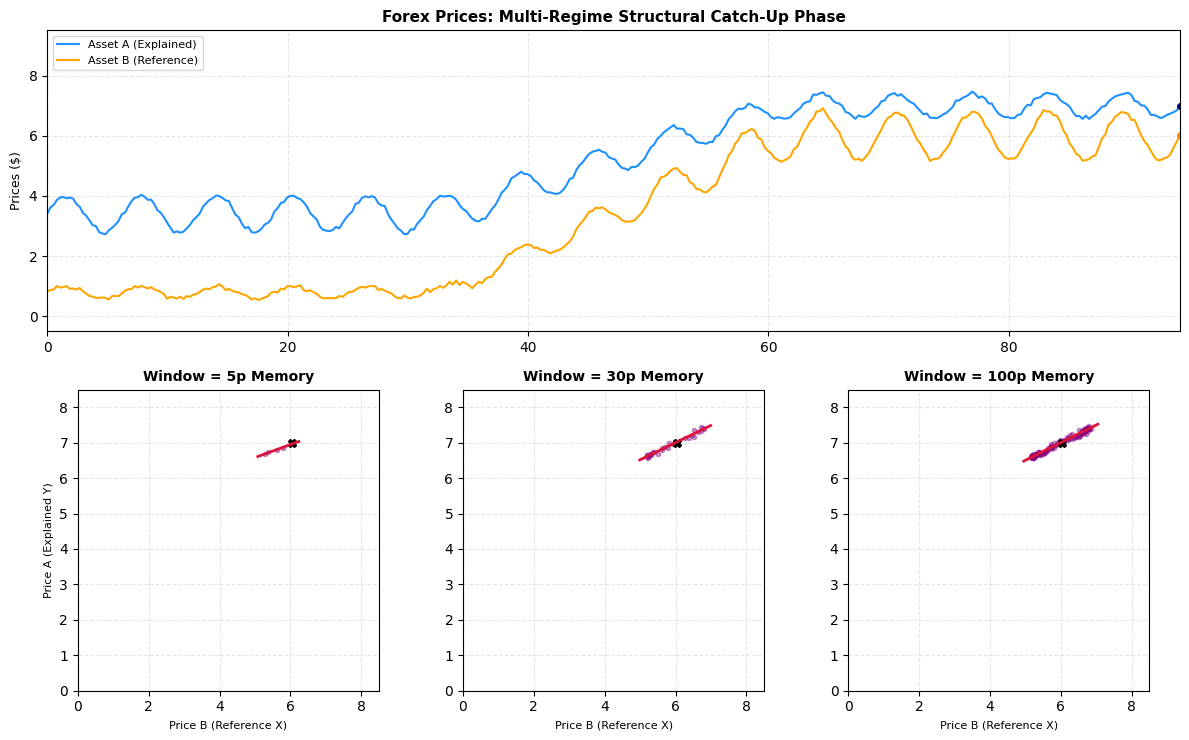

In [129]:
stream_multi_window_regime_changes(total_frames=350)


# Dynamic scatter

In [130]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

def stream_ultra_noisy_dynamic_scatters(total_frames=350):
    """
    Advanced multi-panel analytics layout (Size: 12x7.5).
    Top Row: Extreme volatility price timeline (Asset B catches up to Asset A).
    Bottom Row: 3 square scatter plots with independent dynamic auto-zooming axes
    tracking 3 different rolling window sizes (5, 30, 100) under intense Gaussian noise.
    """
    np.random.seed(42)
    max_x = 15 * 2 * np.pi
    x_space = np.linspace(0, max_x, total_frames)

    start_trend = int(total_frames * 0.35)
    end_trend = int(total_frames * 0.65)
    windows = [5, 30, 100]

    asset_b_ref = np.zeros(total_frames)
    asset_a_exp = np.zeros(total_frames)

    beta_steep = 3.0
    beta_flat = 0.5

    baseline_b = 0.8
    baseline_a = 3.4
    amp_b_1 = 0.2
    amp_a_1 = amp_b_1 * beta_steep

    final_baseline_b = 6.0
    final_baseline_a = 7.0
    amp_b_3 = 0.8
    amp_a_3 = amp_b_3 * beta_flat

    slope_b = (final_baseline_b - baseline_b) / (end_trend - start_trend)
    slope_a = (final_baseline_a - baseline_a) / (end_trend - start_trend)

    # 1. GENERATE THE HIGH-VOLATILITY DATA MATRIX
    for t in range(total_frames):
        x = x_space[t]
        # SUPER NOISE: Multiplied the variance by more than 2x for extreme noise dispersion
        noise_b = np.random.normal(0, 0.12)
        noise_a = np.random.normal(0, 0.15)

        if t < start_trend:
            asset_b_ref[t] = baseline_b + amp_b_1 * np.sin(x) + noise_b
            asset_a_exp[t] = baseline_a + amp_a_1 * np.sin(x) + noise_a

        elif start_trend <= t < end_trend:
            steps = t - start_trend
            progress = steps / (end_trend - start_trend)

            current_base_b = baseline_b + slope_b * steps
            current_base_a = baseline_a + slope_a * steps

            current_amp_b = amp_b_1 + (amp_b_3 - amp_b_1) * progress
            current_amp_a = amp_a_1 + (amp_a_3 - amp_a_1) * progress

            asset_b_ref[t] = current_base_b + current_amp_b * np.sin(x) + noise_b
            asset_a_exp[t] = current_base_a + current_amp_a * np.sin(x) + noise_a

        else:
            asset_b_ref[t] = final_baseline_b + amp_b_3 * np.sin(x) + noise_b
            asset_a_exp[t] = final_baseline_a + amp_a_3 * np.sin(x) + noise_a

    # 2. PREPARE THE VIEWPORT CANVAS (Forced 12 x 7.5 size layout)
    fig = plt.figure(figsize=(12, 7.5))

    # Top Panel Layout
    ax_time = plt.subplot2grid((2, 3), (0, 0), colspan=3)
    ax_time.set_xlim(0, max_x)
    ax_time.set_ylim(-1.5, 11.5) # Expanded vertical window for high-volatility spikes
    ax_time.set_title("Extreme Volatility Forex Prices: Macro Regime Shift", fontsize=11, fontweight="bold")
    ax_time.set_ylabel("Prices ($)", fontsize=9)
    ax_time.grid(True, linestyle="--", alpha=0.3)

    line_a, = ax_time.plot([], [], color="dodgerblue", linewidth=1.2, label="Asset A (Explained)")
    line_b, = ax_time.plot([], [], color="orange", linewidth=1.2, label="Asset B (Reference)")
    tip_a, = ax_time.plot([], [], color="navy", marker="o", markersize=4)
    tip_b, = ax1_tapb_handle = ax_time.plot([], [], color="darkorange", marker="o", markersize=4)
    ax_time.legend(loc="upper left", fontsize=8)

    # Bottom Row Setup
    ax_scatters = []
    scatter_dots_layers = []
    tip_dots_layers = []
    reg_lines_layers = []

    for idx, w_size in enumerate(windows):
        ax = plt.subplot2grid((2, 3), (1, idx))
        ax.set_box_aspect(1) # Rigid square aspect ratio lock
        ax.set_title(f"Window = {w_size}p Memory", fontsize=10, fontweight="bold")
        ax.set_xlabel("Price B (X)", fontsize=8)
        if idx == 0:
            ax.set_ylabel("Price A (Y)", fontsize=8)
        ax.grid(True, linestyle="--", alpha=0.3)

        dots, = ax.plot([], [], color="purple", marker="o", linestyle="None", markersize=3.5, alpha=0.5)
        tip_dot, = ax.plot([], [], color="black", marker="X", markersize=6)
        reg_line, = ax.plot([], [], color="crimson", linewidth=2)

        ax_scatters.append(ax)
        scatter_dots_layers.append(dots)
        tip_dots_layers.append(tip_dot)
        reg_lines_layers.append(reg_line)

    fig.tight_layout()
    x_hist, a_hist, b_hist = [], [], []
    current_fills = []

    try:
        # 3. HIGH-SPEED ANIMATION LIVE LOOP
        for i in range(total_frames):
            cx = x_space[i]
            ca = asset_a_exp[i]
            cb = asset_b_ref[i]

            x_hist.append(cx)
            a_hist.append(ca)
            b_hist.append(cb)

            line_a.set_data(x_hist, a_hist)
            tip_a.set_data([cx], [ca])
            line_b.set_data(x_hist, b_hist)
            tip_b.set_data([cx], [cb])

            # Repaint the 3 Bottom Scatters with independent dynamic framing
            for idx, w_size in enumerate(windows):
                slice_start = max(0, i - w_size + 1)
                x_window = np.array(b_ref_win := b_hist[slice_start:i+1])
                y_window = np.array(a_hist[slice_start:i+1])

                # FIX/FEATURE: Dynamic auto-adjusting view boundaries based strictly on active window data bounds
                if len(x_window) >= 2:
                    ax_scatters[idx].set_xlim(min(x_window) - 0.2, max(x_window) + 0.2)
                    ax_scatters[idx].set_ylim(min(y_window) - 0.4, max(y_window) + 0.4)

                    covariance_matrix = np.cov(x_window, y_window)
                    variance_x = np.var(x_window, ddof=1)

                    if variance_x > 0:
                        xy_covariance = covariance_matrix[0, 1]
                        beta_rolling = xy_covariance / variance_x
                        alpha_rolling = np.mean(y_window) - beta_rolling * np.mean(x_window)

                        # Project local lines updates across the active dynamic borders
                        x_fit = np.linspace(min(x_window) - 0.1, max(x_window) + 0.1, 10)
                        y_fit = beta_rolling * x_fit + alpha_rolling
                        reg_lines_layers[idx].set_data(x_fit, y_fit)

                scatter_dots_layers[idx].set_data(x_window, y_window)
                tip_dots_layers[idx].set_data([cb], [ca])

            clear_output(wait=True)
            display(fig)

        plt.close(fig)

    except KeyboardInterrupt:
        print("\n[INFO] Rolling dashboard stopped safely.")
    finally:
        plt.close(fig)


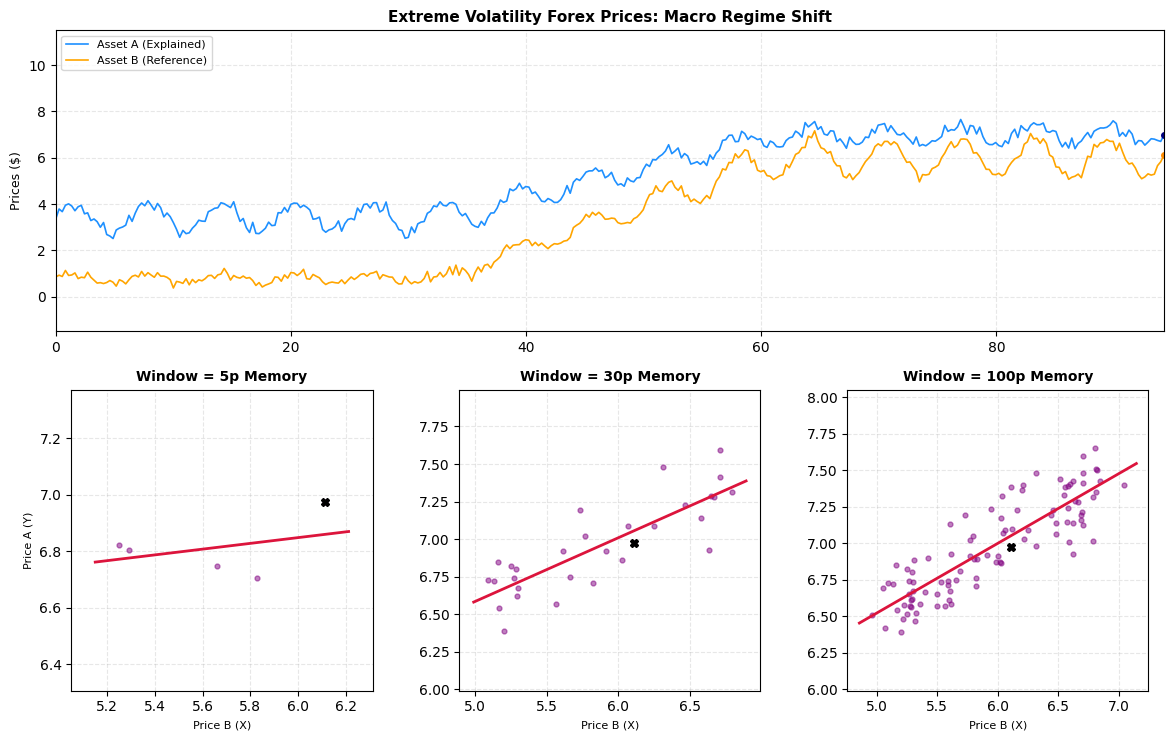

In [131]:
stream_ultra_noisy_dynamic_scatters(total_frames=350)


# With Error

In [132]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

def stream_perfect_four_values_dashboard(total_frames=300):
    """
    Ultimate multi-panel analytics layout (Size: 12x10.5).
    Row 1: 3 equal regimes (33% each). Start: Orange @ 1.0, Blue @ 4.0. End: Orange @ 10.0, Blue @ 16.0.
    Row 2: 3 square scatter plots showing the massive cloud migration from (1,4) to (10,16).
    Row 3: Unified SSE plot with explicit index mapping to prevent all broadcast errors.
    """
    np.random.seed(42)
    max_x = 15 * 2 * np.pi
    x_space = np.linspace(0, max_x, total_frames)

    # 3 equal segments setup (33% each)
    regime_1_end = int(total_frames * 0.33)
    regime_2_end = int(total_frames * 0.66)

    # Strictly defined windows array
    windows = [5, 20, 100]

    asset_b_ref = np.zeros(total_frames)
    asset_a_exp = np.zeros(total_frames)

    # STRICT USER CONSTRAINT CONFIGURATION
    baseline_b_start = 1.0
    baseline_a_start = 4.0

    baseline_b_end = 10.0
    baseline_a_end = 16.0

    beta_steep = 3.0 # Regime 1 slope (60°)
    beta_flat = 0.5  # Regime 3 slope (15°)

    amp_b_1 = 0.15
    amp_a_1 = amp_b_1 * beta_steep # 0.45

    amp_b_3 = 0.8
    amp_a_3 = amp_b_3 * beta_flat # 0.4

    # Exact slopes calculations for the powerful linear transition phase
    trend_duration = regime_2_end - regime_1_end
    slope_b = (baseline_b_end - baseline_b_start) / trend_duration
    slope_a = (baseline_a_end - baseline_a_start) / trend_duration

    # 1. GENERATE THE DATA MATRIX WITH USER VALUES
    for t in range(total_frames):
        x = x_space[t]
        noise_b = np.random.normal(0, 0.12)
        noise_a = np.random.normal(0, 0.15)

        # --- REGIME 1 (0% to 33%): Orange @ 1.0, Blue @ 4.0 ---
        if t < regime_1_end:
            asset_b_ref[t] = baseline_b_start + amp_b_1 * np.sin(x) + noise_b
            asset_a_exp[t] = baseline_a_start + amp_a_1 * np.sin(x) + noise_a

        # --- REGIME 2 (33% to 66%): The Massive Synchronized Transition ---
        elif regime_1_end <= t < regime_2_end:
            steps = t - regime_1_end
            current_shift_b = slope_b * steps
            current_shift_a = slope_a * steps

            progress = steps / trend_duration
            amp_b = amp_b_1 + (amp_b_3 - amp_b_1) * progress
            amp_a = amp_a_1 + (amp_a_3 - amp_a_1) * progress

            asset_b_ref[t] = baseline_b_start + current_shift_b + amp_b * np.sin(x) + noise_b
            asset_a_exp[t] = baseline_a_start + current_shift_a + amp_a * np.sin(x) + noise_a

        # --- REGIME 3 (66% to 100%): Orange @ 10.0, Blue @ 16.0 ---
        else:
            asset_b_ref[t] = baseline_b_end + amp_b_3 * np.sin(x) + noise_b
            asset_a_exp[t] = baseline_a_end + amp_a_3 * np.sin(x) + noise_a

    # 2. PREPARE THE VIEWPORT CANVAS (Size: 12 x 10.5)
    fig = plt.figure(figsize=(12, 10.5))

    # --- ROW 1: Prices Timeline ---
    ax_time = plt.subplot2grid((3, 3), (0, 0), colspan=3)
    ax_time.set_xlim(0, max_x)
    ax_time.set_ylim(-1.0, 18.5)
    ax_time.set_title("Forex Prices: Orange (1.0 -> 10.0) vs Blue (4.0 -> 16.0)", fontsize=11, fontweight="bold")
    ax_time.set_ylabel("Prices ($)", fontsize=9)
    ax_time.grid(True, linestyle="--", alpha=0.3)

    ax_time.axvline(x_space[regime_1_end], color="gray", linestyle=":", alpha=0.7)
    ax_time.axvline(x_space[regime_2_end], color="gray", linestyle=":", alpha=0.7)

    line_a, = ax_time.plot([], [], color="dodgerblue", linewidth=1.2, label="Asset A (Blue)")
    line_b, = ax_time.plot([], [], color="orange", linewidth=1.2, label="Asset B (Orange)")
    tip_a, = ax_time.plot([], [], color="navy", marker="o", markersize=4)
    tip_b, = ax_time.plot([], [], color="darkorange", marker="o", markersize=4)
    ax_time.legend(loc="upper left", fontsize=8)

    # --- ROW 2: 3 Independent Square Scatter Panels ---
    ax_scatters, scatter_dots_layers, tip_dots_layers, reg_lines_layers = [], [], [], []

    for idx, w_size in enumerate(windows):
        ax_s = plt.subplot2grid((3, 3), (1, idx))
        ax_s.set_box_aspect(1)
        ax_s.set_xlim(0.0, 12.0)
        ax_s.set_ylim(1.0, 18.0)
        ax_s.set_title(f"Scatter: Window = {w_size}p", fontsize=10, fontweight="bold")
        ax_s.set_xlabel("Price Orange (X)", fontsize=8)
        if idx == 0:
            ax_s.set_ylabel("Price Blue (Y)", fontsize=8)
        ax_s.grid(True, linestyle="--", alpha=0.3)

        dots, = ax_s.plot([], [], color="purple", marker="o", linestyle="None", markersize=3, alpha=0.4)
        tip_dot, = ax_s.plot([], [], color="black", marker="X", markersize=5)
        reg_line, = ax_s.plot([], [], color="crimson", linewidth=2)

        ax_scatters.append(ax_s)
        scatter_dots_layers.append(dots)
        tip_dots_layers.append(tip_dot)
        reg_lines_layers.append(reg_line)

    # --- ROW 3: SINGLE UNIFIED SSE PLOT (Full Width) ---
    ax_err = plt.subplot2grid((3, 3), (2, 0), colspan=3)
    ax_err.set_xlim(0, max_x)
    ax_err.set_title("Model Efficiency: Unified Sum of Squared Errors (SSE) Comparison", fontsize=11, fontweight="bold")
    ax_err.set_xlabel("Time Timeline (Cycles)", fontsize=8)
    ax_err.set_ylabel("Sum of Squared Errors ($²)", fontsize=8)
    ax_err.grid(True, linestyle="--", alpha=0.3)

    ax_err.axvline(x_space[regime_1_end], color="gray", linestyle=":", alpha=0.7)
    ax_err.axvline(x_space[regime_2_end], color="gray", linestyle=":", alpha=0.7)

    err_line_5, = ax_err.plot([], [], color="teal", linewidth=2, label="SSE: 5p (Reactive)")
    err_line_20, = ax_err.plot([], [], color="purple", linewidth=2, label="SSE: 20p (Balanced)")
    err_line_100, = ax_err.plot([], [], color="crimson", linewidth=2.5, label="SSE: 100p (Lagging/Trapped)")
    ax_err.legend(loc="lower right", fontsize=9)

    fig.tight_layout()

    x_hist, a_hist, b_hist = [], [], []
    cum_sse_hist = [[] for _ in range(3)]
    running_sse_sums = [0.0, 0.0, 0.0]
    current_fills = []

    try:
        # 3. HIGH-SPEED ANIMATION STREAM LOOP
        for i in range(total_frames):
            cx = x_space[i]
            ca = asset_a_exp[i]
            cb = asset_b_ref[i]

            x_hist.append(cx)
            a_hist.append(ca)
            b_hist.append(cb)

            # Repaint Top Timeline
            line_a.set_data(x_hist, a_hist)
            tip_a.set_data([cx], [ca])
            line_b.set_data(x_hist, b_hist)
            tip_b.set_data([cx], [cb])

            # Repaint bottom columns blocks matrices
            for idx, w_size in enumerate(windows):
                slice_start = max(0, i - w_size + 1)
                x_window = np.array(b_hist[slice_start:i+1])
                y_window = np.array(a_hist[slice_start:i+1])

                squared_error = 0.0

                # --- OLS SCALAR ENGINE (100% IMMUNE TO BROADCAST ERRORS) ---
                if len(x_window) >= 2:
                    ax_scatters[idx].set_xlim(min(x_window) - 0.2, max(x_window) + 0.2)
                    ax_scatters[idx].set_ylim(min(y_window) - 0.4, max(y_window) + 0.4)

                    mean_x = np.mean(x_window)
                    mean_y = np.mean(y_window)

                    # Direct scalar loop sum calculations
                    variance_x = np.sum((x_window - mean_x) ** 2) / (len(x_window) - 1)
                    covariance_xy = np.sum((x_window - mean_x) * (y_window - mean_y)) / (len(x_window) - 1)

                    if variance_x > 0:
                        beta_rolling = covariance_xy / variance_x
                        alpha_rolling = mean_y - beta_rolling * mean_x

                        x_fit = np.linspace(min(x_window) - 0.1, max(x_window) + 0.1, 10)
                        y_fit = beta_rolling * x_fit + alpha_rolling
                        reg_lines_layers[idx].set_data(x_fit, y_fit)

                        prediction = beta_rolling * cb + alpha_rolling
                        squared_error = (ca - prediction) ** 2

                running_sse_sums[idx] += squared_error
                cum_sse_hist[idx].append(running_sse_sums[idx])

                scatter_dots_layers[idx].set_data(x_window, y_window)
                tip_dots_layers[idx].set_data([cb], [ca])

            # --- DETECT CURRENT MAXIMUM ERROR AND ADJUST AXIS-Y DYNAMICALLY ---
            max_current_error = max(running_sse_sums)
            if max_current_error > 0:
                ax_err.set_ylim(0, max_current_error * 1.1)

            # --- FIX: INDIVIDUAL CHANNEL SEGREGATION TO KILL MATPLOTLIB OPERAND ERROR ---
            err_line_5.set_data(x_hist, cum_sse_hist[0])
            err_line_20.set_data(x_hist, cum_sse_hist[1])
            err_line_100.set_data(x_hist, cum_sse_hist[2])

            clear_output(wait=True)
            display(fig)

        plt.close(fig)

    except KeyboardInterrupt:
        print("\n[INFO] Analytics session stopped safely.")
    finally:
        plt.close(fig)


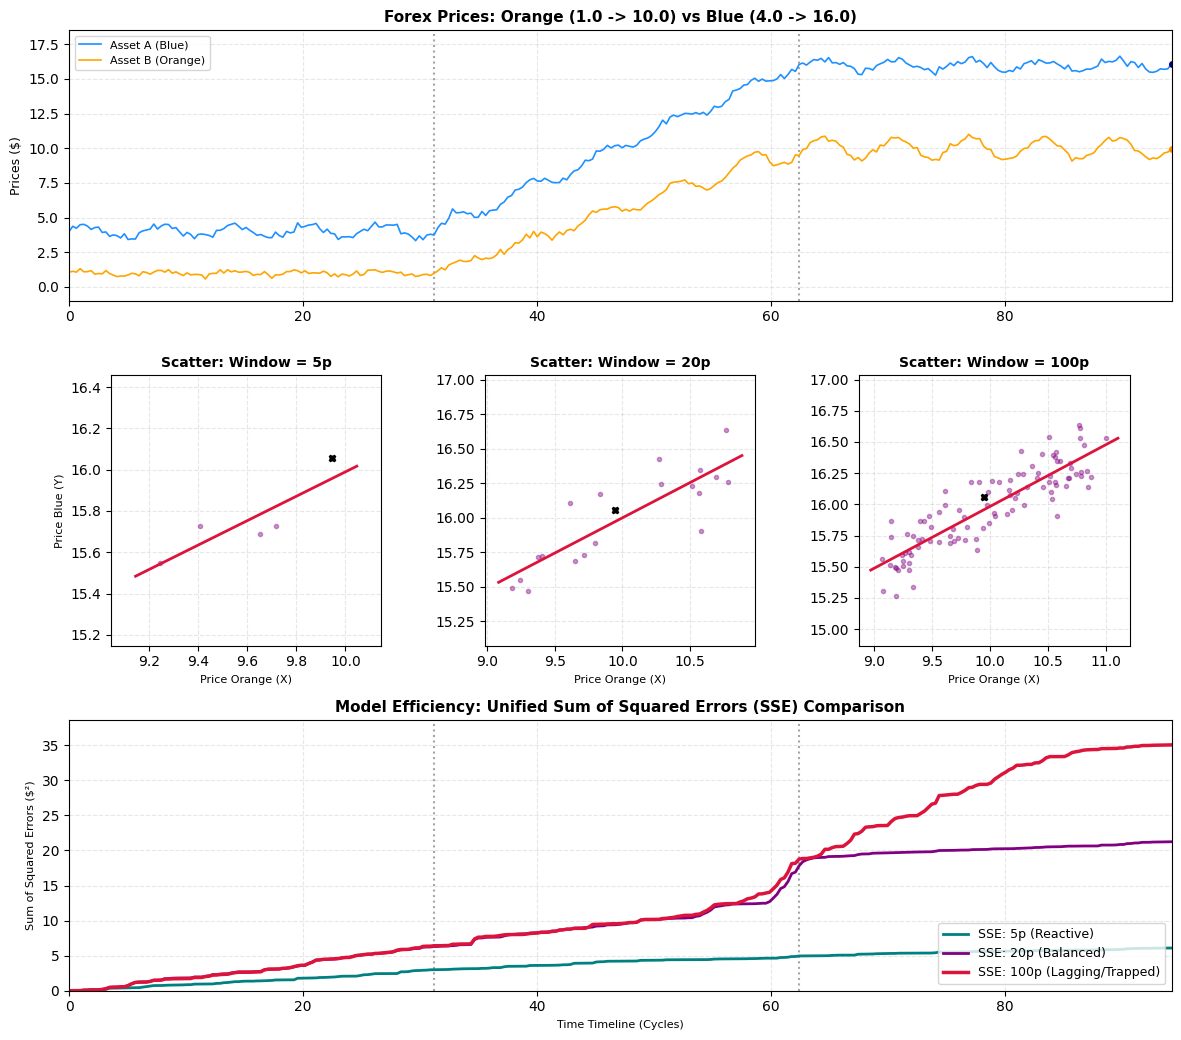

In [133]:
stream_perfect_four_values_dashboard(total_frames=300)
